# Chromatin Loops Layout Filtration

This notebook filters chromatin loop layouts based on quality metrics and prepares data for analysis.

In [ ]:
import pandas as pdfrom tqdm import tqdmimport osimport jsonimport seaborn as snsimport coolerimport bioframeimport cooltoolsfrom os import listdirfrom os.path import isfile, join, basenamefrom io import StringIOimport warningsimport math import numpy as npimport matplotlib.pyplot as pltfrom dotenv import load_dotenvassert os.environ['CONDA_DEFAULT_ENV'] == "hic"

# Chromatin Loops Layout Filtration

This notebook filters chromatin loop layouts based on quality metrics and prepares data for analysis.

# 1. Preprare needed files

In [3]:
def get_hg38_arms():    hg38_chromsizes = bioframe.fetch_chromsizes('hg38')    hg38_cens = bioframe.fetch_centromeres('hg38')    hg38_arms = bioframe.make_chromarms(hg38_chromsizes, hg38_cens)    return hg38_arms[hg38_arms.chrom!='chrM'].reset_index(drop=True)def get_source2map(merged_bedpe_clf_2_filtered, maps2loops):    source2map = {}    for k in merged_bedpe_clf_2_filtered.source.unique():        name = k.split(".sampled.dro")[0]        map = [k for k,i in maps2loops.items() if name in i]        assert len(map) == 1        source2map[k] = map[0].split('/')[-1]    return source2map    

In [7]:
path_to_maps = os.getenv("PATH_TO_PROCESSED_MAPS")path_to_maps_expected = "../0.additional_data/expected_maps/"path_to_loops_clusters_data = "./loops_cooltools_data_noSexChromosomes/loops_clusters_data_15kb"

In [8]:
name_appender = ""save_name = "loops_SZ_vs_Healthy"merged_all_clusters = pd.read_pickle(f"{path_to_loops_clusters_data}/{save_name}_calculated_clusters_all{name_appender}.pickle")hg38_arms = get_hg38_arms() 

In [9]:
maps2loops = json.load(open('./loops_chromosight_data_noSexChromosomes/loops_supporting_files/maps2loops_mapping.json'))sources = merged_all_clusters.source.unique()

In [10]:
maps = list(maps2loops.keys())maps.sort()maps = [i.split("/")[-1] for i in maps]sources = merged_all_clusters.source.unique()sources.sort()source2map = dict(zip(sources, maps))

In [20]:
def get_hg38_arms():    """    The function gets sizes of chromosomes arms by HG38 genome build        """        hg38_chromsizes = bioframe.fetch_chromsizes('hg38')    hg38_cens = bioframe.fetch_centromeres('hg38')    hg38_arms = bioframe.make_chromarms(hg38_chromsizes, hg38_cens)    return hg38_arms[hg38_arms.chrom!='chrM'].reset_index(drop=True)   def get_expected(source, source2map, hg38_arms, nproc=17):      print(source, source2map[source])    clr = cooler.Cooler(f'{path_to_maps}/{source2map[source]}::/resolutions/{15000}')    reduced_maps2loops = source2map[source].split('.mcool', 0)[0]    expected_per_chr = cooltools.expected_cis(clr, view_df=hg38_arms, nproc=16)    expected_per_chr.to_pickle(f'{path_to_maps_expected}/{reduced_maps2loops}_perChrArm_Updated2025.pickle')    return expected_per_chrhg38_arms = get_hg38_arms()

In [21]:
maps_stored = {}for source in sources:    maps_stored[source] = {}    map_name = source2map[source]    print(source, map_name)    clr = cooler.Cooler(f'{path_to_maps}/{source2map[source]}::/resolutions/{15000}')    maps_stored[source]['clr'] = clr    reduced_maps2loops = source2map[source].split('.mcool', 0)[0]    maps_stored[source]['expected'] = get_expected(source, source2map, hg38_arms)

HC-2Mplus_20kb_cooltools_loops_sorted_with_intensity_removed_duplicates_noHeader.bed HC-2Mplus.sampled.drop_diag.1kb.mcool
HC-2Mplus_20kb_cooltools_loops_sorted_with_intensity_removed_duplicates_noHeader.bed HC-2Mplus.sampled.drop_diag.1kb.mcool
HC-318plus_20kb_cooltools_loops_sorted_with_intensity_removed_duplicates_noHeader.bed HC-318plus.sampled.drop_diag.1kb.mcool
HC-318plus_20kb_cooltools_loops_sorted_with_intensity_removed_duplicates_noHeader.bed HC-318plus.sampled.drop_diag.1kb.mcool
HC-3Mplus_20kb_cooltools_loops_sorted_with_intensity_removed_duplicates_noHeader.bed HC-3Mplus.sampled.drop_diag.1kb.mcool
HC-3Mplus_20kb_cooltools_loops_sorted_with_intensity_removed_duplicates_noHeader.bed HC-3Mplus.sampled.drop_diag.1kb.mcool
HC-91plus_20kb_cooltools_loops_sorted_with_intensity_removed_duplicates_noHeader.bed HC-91plus.sampled.drop_diag.1kb.mcool
HC-91plus_20kb_cooltools_loops_sorted_with_intensity_removed_duplicates_noHeader.bed HC-91plus.sampled.drop_diag.1kb.mcool
HC24plus_20k

# 2. Identify params

In [23]:
def get_internal_and_not_internal(merged_all_clusters_source, source, res= 15_000):    """    Processes the merged clusters source data to separate internal and cluster-based calculations.    Parameters:    - merged_all_clusters_source (pd.DataFrame): DataFrame containing cluster source data.    - source (str): Identifier for the data source.    Returns:    Tuple[pd.DataFrame, pd.DataFrame]: A tuple containing DataFrames for internal calculations and cluster calculations.    """    merged_all_clusters_source = merged_all_clusters_source[        ['chrom1', 'start1', 'end1', 'chrom2', 'start2', 'end2', 'calculation', 'cluster', 'source']    ].sort_values(['chrom1', 'start1', 'end1'])    cluster_df = merged_all_clusters_source[merged_all_clusters_source['calculation'] == "from_cluster"].copy()        resolution_diff = set(cluster_df['end1'] - cluster_df['start1'])    if resolution_diff == {res*3}:        adjustment_value = res        cluster_df['start1'] += adjustment_value        cluster_df['end1'] -= adjustment_value        cluster_df['start2'] += adjustment_value        cluster_df['end2'] -= adjustment_value    elif resolution_diff == {res}:        print('All resolutions set to 15kb')    else:        raise ValueError('Not valid resolution')    internal_df = merged_all_clusters_source[merged_all_clusters_source['calculation'] != "from_cluster"]        return internal_df, cluster_dfdef create_matrix_calculated(source, merged_all_clusters_cluster, res=15000):    """    Creates a matrix from the calculated pileup stack for a given source and cluster data.    Parameters:    - source (str): Identifier for the data source.    - merged_all_clusters_cluster (pd.DataFrame): DataFrame containing cluster data.    Returns:    Tuple[np.ndarray, np.ndarray]: A tuple containing the stack and the mean matrix.    """    flank_size = 3 * res      stack = cooltools.pileup(        maps_stored[source]['clr'],        merged_all_clusters_cluster,        view_df=hg38_arms,        expected_df=maps_stored[source]['expected'],        flank=flank_size    )        mean_matrix = np.nanmean(stack, axis=0)    return stack, mean_matrix

In [24]:
def create_matrix_calculated_test_large_flank(source, merged_all_clusters_cluster, flank=10*15000):        stack = cooltools.pileup(maps_stored[source]['clr'],                              merged_all_clusters_cluster,                              view_df=hg38_arms,                              expected_df=maps_stored[source]['expected'],                              flank=flank)        mtx = np.nanmean(stack, axis=0)    return mtx, stackdef plot_loop(mtx_from_cluster, resolution = 15000):        flank=3*resolution    plt.imshow(        np.log2(mtx_from_cluster),        cmap='coolwarm')        plt.colorbar(label = 'log2 mean obs/exp')    ticks_pixels = np.linspace(0, flank*2//resolution,5)    ticks_kbp = ((ticks_pixels-ticks_pixels[-1]/2)*resolution//1000).astype(int)    plt.xticks(ticks_pixels, ticks_kbp)    plt.yticks(ticks_pixels, ticks_kbp)    plt.xlabel('relative position, kbp')    plt.ylabel('relative position, kbp')        plt.show()def get_ratio_3to3(stack_from_internal):    loops_ratios_internal = []    mean_central_all = []    for loop in stack_from_internal:        central_3x3 = loop[2:5, 2:5]        mean_central = np.mean(central_3x3)        arr_copy = loop.copy()        arr_copy[2:5, 2:5] = np.nan        mean_others = np.nanmean(arr_copy)        loops_ratios_internal.append(mean_central / mean_others)        mean_central_all.append(mean_central)    return loops_ratios_internal, mean_central_all

In [25]:
source = merged_all_clusters.source.unique()[0]print(source)merged_all_clusters_source = merged_all_clusters[merged_all_clusters.source == source]merged_all_clusters_internal, merged_all_clusters_cluster = get_internal_and_not_internal(merged_all_clusters_source, source)

SZ6plus_20kb_cooltools_loops_sorted_with_intensity_removed_duplicates_noHeader.bed
All resolutions set to 15kb


In [26]:
test_mtx_from_cluster, test_stack_cluster = create_matrix_calculated_test_large_flank(source, merged_all_clusters_cluster)test_mtx_from_internal, test_stack_internal = create_matrix_calculated_test_large_flank(source, merged_all_clusters_internal)

In [27]:
new_df = merged_all_clusters_internal.copy()for chrom in new_df['chrom1'].unique().copy():    max_end1 = new_df[new_df['chrom1'] == chrom]['end1'].max()    max_end2 = new_df[new_df['chrom1'] == chrom]['end2'].max()    max_end = min(max_end1, max_end2)        chrom_df = new_df[new_df['chrom1'] == chrom]    chrom_df['start1'] = np.random.randint(0, max_end - 15000, size=len(chrom_df)).copy()    chrom_df['start2'] = chrom_df['start1'] + np.random.randint(0, chrom_df['start2'].max() - chrom_df['start1'], size=len(chrom_df)).copy()        chrom_df['end1'] = chrom_df['start1'] + 15000    chrom_df['end2'] = chrom_df['start2'] + 15000    chrom_df['end1'] = chrom_df['end1'].where(chrom_df['end1'] <= max_end1, max_end1).copy()    chrom_df['end2'] = chrom_df['end2'].where(chrom_df['end2'] <= max_end2, max_end2).copy()        new_df.update(chrom_df)new_df.start1 = new_df.start1.astype(int)new_df.end1 = new_df.end1.astype(int)new_df.start2 = new_df.start2.astype(int)new_df.end2 = new_df.end2.astype(int)

In [28]:
stack_from_internal_permutated, mtx_from_internal_permutated = create_matrix_calculated(source, new_df)stack_from_cluster, mtx_from_cluster = create_matrix_calculated(source, merged_all_clusters_cluster)stack_from_internal, mtx_from_internal = create_matrix_calculated(source, merged_all_clusters_internal)

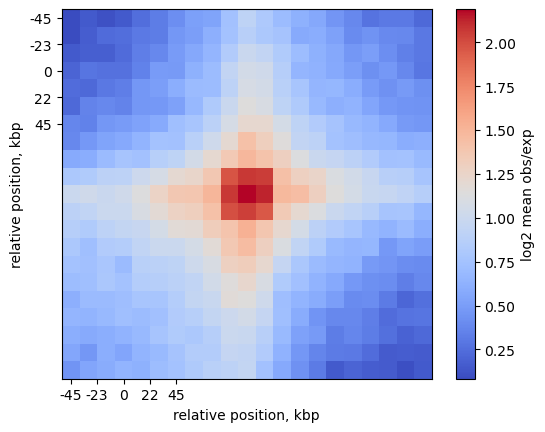

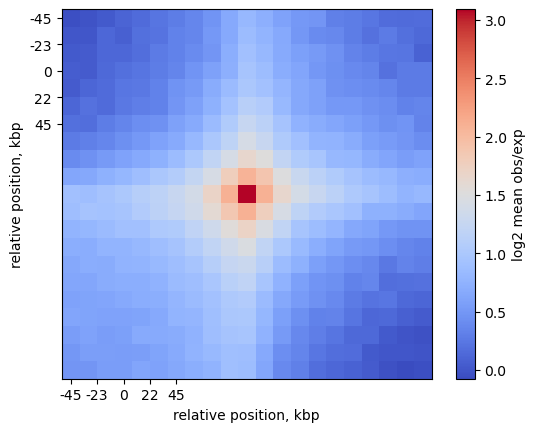

In [29]:
plot_loop(test_mtx_from_cluster)plot_loop(test_mtx_from_internal)

In [30]:
loops_ratios_internal,mean_central_all =  get_ratio_3to3(stack_from_internal)loops_ratios_internal = [v for v in loops_ratios_internal if not math.isnan(v) and not math.isinf(v)]loops_ratios_cluster,mean_central_all =  get_ratio_3to3(stack_from_cluster)loops_ratios_cluster = [i for i in loops_ratios_cluster if not np.isnan(i)]loops_ratios_internal_perm, mean_central_all_perm =  get_ratio_3to3(stack_from_internal_permutated)loops_ratios_internal_perm = [v for v in loops_ratios_internal_perm if not math.isnan(v) and not math.isinf(v)]

# 3. Implement calculation

In [31]:
def process_clusters(merged_all_clusters, save_name):    """    Processes clusters from the merged data, calculates loop ratios,    and saves the results to a pickle file.    Args:        merged_all_clusters (pd.DataFrame): DataFrame containing the cluster data.        save_name (str): Base name for the output file.    """    merged_all_clusters_concat_all = pd.DataFrame()    lower_values, lower_values_central = [], []    for source in tqdm(merged_all_clusters['source'].unique(), desc="Processing Sources"):        print(f"Processing source: {source}")                merged_all_clusters_source = merged_all_clusters[merged_all_clusters['source'] == source]        # Get internal and non-internal clusters        merged_all_clusters_internal, merged_all_clusters_cluster = get_internal_and_not_internal(merged_all_clusters_source, source)        stack_from_cluster, mtx_from_cluster = create_matrix_calculated(source, merged_all_clusters_cluster)        stack_from_internal, mtx_from_internal = create_matrix_calculated(source, merged_all_clusters_internal)        # Calculate loop ratios and means        loops_ratios_internal, mean_central_internal = get_ratio_3to3(stack_from_internal)        loops_ratios_cluster, mean_central_cluster = get_ratio_3to3(stack_from_cluster)        assert merged_all_clusters_internal['cluster'].nunique() == len(loops_ratios_internal) == len(stack_from_internal)        assert merged_all_clusters_cluster['cluster'].nunique() == len(loops_ratios_cluster) == len(stack_from_cluster)        # Calculate lower quantile values        loops_ratios_internal_for_calculation = [v for v in loops_ratios_internal if not math.isnan(v) and not math.isinf(v)]        lower_value = np.quantile(loops_ratios_internal_for_calculation, 0.1)        lower_values.append(lower_value)        mean_central_cluster_for_calculation = [v for v in mean_central_cluster if not math.isnan(v) and not math.isinf(v)]        lower_value_central = np.quantile(mean_central_cluster_for_calculation, 0.1)        lower_values_central.append(lower_value_central)        merged_all_clusters_internal['loop_ratio'] = loops_ratios_internal        merged_all_clusters_cluster['loop_ratio'] = loops_ratios_cluster        merged_all_clusters_internal['mean_central'] = mean_central_internal        merged_all_clusters_cluster['mean_central'] = mean_central_cluster        # Concatenate internal and cluster data        merged_all_clusters_concat = pd.concat([merged_all_clusters_internal, merged_all_clusters_cluster])                assert merged_all_clusters_concat['cluster'].nunique() == merged_all_clusters_source['cluster'].nunique()        assert merged_all_clusters_concat.shape[0] == merged_all_clusters_source.shape[0]        merged_all_clusters_concat['is_loop_loop_ratio'] = merged_all_clusters_concat['loop_ratio'].apply(            lambda x: not pd.isna(x) and x > lower_value        )        merged_all_clusters_concat['is_loop_loop_central'] = merged_all_clusters_concat['mean_central'].apply(            lambda x: not pd.isna(x) and x > lower_value_central        )        merged_all_clusters_concat_all = pd.concat([merged_all_clusters_concat_all, merged_all_clusters_concat], ignore_index=True)    assert merged_all_clusters.shape[0] == merged_all_clusters_concat_all.shape[0]    output_path = f"{path_to_loops_clusters_data}/{save_name}_calculated_clusters_all_withLoopNotation_withCentral.pickle"    merged_all_clusters_concat_all.to_pickle(output_path)    print(f"Data saved to {output_path}")    return merged_all_clusters_concat_all

In [33]:
save_name = 'loops_clustering_SZ_vs_Healthy'merged_all_clusters_concat_all = process_clusters(merged_all_clusters, save_name)

Processing Sources:   0%|                                                                                                                  | 0/12 [00:00<?, ?it/s]

Processing source: SZ6plus_20kb_cooltools_loops_sorted_with_intensity_removed_duplicates_noHeader.bed
All resolutions set to 15kb


Processing Sources:   8%|████████▊                                                                                                 | 1/12 [00:28<05:17, 28.85s/it]

Processing source: SZ20plus_20kb_cooltools_loops_sorted_with_intensity_removed_duplicates_noHeader.bed
All resolutions set to 15kb


Processing Sources:  17%|█████████████████▋                                                                                        | 2/12 [01:04<05:30, 33.06s/it]

...

Processing source: HC-91plus_20kb_cooltools_loops_sorted_with_intensity_removed_duplicates_noHeader.bed
All resolutions set to 15kb


Processing Sources:  92%|████████████████████████████████████████████████████████████████████████████████████████████████▎        | 11/12 [05:23<00:28, 28.46s/it]

Processing source: HC-318plus_20kb_cooltools_loops_sorted_with_intensity_removed_duplicates_noHeader.bed
All resolutions set to 15kb


Processing Sources: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████| 12/12 [05:58<00:00, 29.85s/it]

Data saved to ./loops_cooltools_data_noSexChromosomes/loops_clusters_data_15kb/loops_clustering_SZ_vs_Healthy_calculated_clusters_all_withLoopNotation_withCentral.pickle


In [35]:
df = merged_all_clusters[['cluster', 'source','intensity_median', 'intensity_mean']].drop_duplicates()df = merged_all_clusters_concat_all.merge(df ,on = ['cluster', 'source'])output_path = f"{path_to_loops_clusters_data}/{save_name}_calculated_clusters_all_withLoopNotation_withCentral_Final.pickle"df.to_pickle(output_path)